In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')
import arviz as az
import pymc as pm
#from main_pool import Main
#from calibr_funcs import plot_results
import calibr_funcs
from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel
import scipy.stats as stats
from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data
from source.autoencoder import AESurrogateModel
#pip install -e git+https://github.com/Mpkosh/Mathematics-of-Epidemics-on-Networks.git@my_changes#egg=eon

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
import surr_on_real.epid_data as epd
import surr_on_real.abc_calib as abc_calib
from datetime import datetime

%load_ext autoreload
%autoreload 2

pm.__version__  

'5.25.1'

## stuff

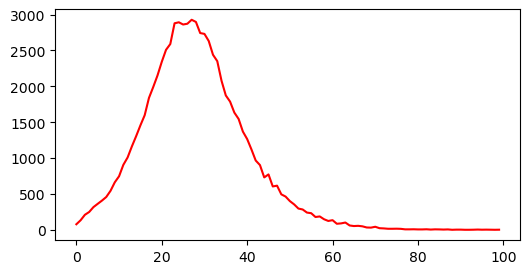

In [2]:
'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
plt.subplots(figsize=(6,3))

observed_data = pd.read_csv('incidence_synthetic_curve.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)

plt.plot(observed_data,color='red')

In [3]:
df_c = pd.read_excel('../network_hybrid_33/sum_intensity/data1990_2019.xlsx')
df_c = df_c[(df_c.cld_year >= 2009)&(df_c.cld_year < 2020)]

# qty_total - qty_15
# remove people older than 15, because children's data has less underreporting
df_c['qty_lt15'] = df_c['qty_total'] - df_c['qty_15']
df_c['wd_lt15'] = df_c['wd_total'] - df_c['wd_15']

# we combine [40w:52w] year x  AND  [0w:20w] year x+1
df_c = df_c[~((df_c.cld_year == 2009)&(df_c.week_number < 40))]
df_c = df_c[~((df_c.cld_year == 2019)&(df_c.week_number > 40))]
df_c = df_c[((df_c.week_number >= 40)|(df_c.week_number <= 39))]
df_c = df_c[['town_name','cld_year','week_number','qty_lt15','wd_lt15','qty_total','qty_15','wd_total','wd_15']]
df_c['years_part'] = ''
ntowns = df_c.town_name.nunique()
df_c = df_c[df_c.week_number!=53]
nweeks =  df_c.week_number.nunique()

for i in np.arange(2009,2019):
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=39)),
             'years_part'] = f'{i}{i+1}'
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=39)),
             'yp_week'] = [*np.arange(1,nweeks+1)]*ntowns
    
df_c.head()

,town_name,cld_year,week_number,qty_lt15,wd_lt15,qty_total,qty_15,wd_total,wd_15,years_part,yp_week
1030,Архангельск,2009,40,49907.0,1610.0,354682.0,304775.0,2569.0,959.0,20092010,1.0
1031,Архангельск,2009,41,49907.0,1364.0,354682.0,304775.0,2201.0,837.0,20092010,2.0
1032,Архангельск,2009,42,49907.0,1535.0,354682.0,304775.0,2279.0,744.0,20092010,3.0
1033,Архангельск,2009,43,49907.0,1635.0,354682.0,304775.0,2312.0,677.0,20092010,4.0
1034,Архангельск,2009,44,49907.0,1627.0,354682.0,304775.0,2406.0,779.0,20092010,5.0


In [5]:
df_c[(df_c.town_name=='Самара')&(df_c.years_part=='20172018')].shape

(52, 11)

<Axes: xlabel='yp_week', ylabel='wd_total'>

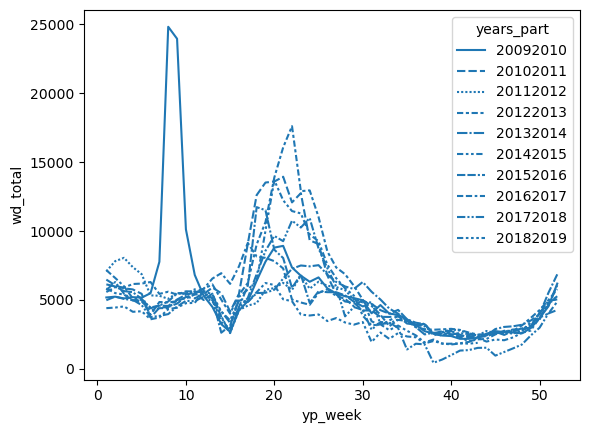

In [6]:
plt.subplots(1,1,figsize=(5,3))
sns.lineplot(x = df_c[df_c.town_name=='Самара'].yp_week,
            y = df_c[df_c.town_name=='Самара'].wd_total, 
             style=df_c[df_c.town_name=='Самара'].years_part)

In [7]:
pcr = pd.read_csv('surr_on_real/ПЦР_Самара_Челябинск_Волгоград_Спб_18_11_2024.csv', 
            sep=';', header=1).iloc[1:,:7]
pcr_table_from_excel_to_python = {
    "date": "Дата",
    "tested_total": "Число образцов тестированных на грипп",
    "tested_strain_0": "A (субтип не определен)",
    "tested_strain_1": "A(H1)pdm09",
    "tested_strain_2": "A(H3)",
    "tested_strain_3": "B",
}
pcr.head(2)

,Unnamed: 0,Unnamed: 1,Число образцов тестированных на грипп,A (субтип не определен),A(H1)pdm09,A(H3),B
1,2010.1 (04.01.2010 - 10.01.2010),Н,0,0,0,0,0
2,2010.2 (11.01.2010 - 17.01.2010),Н,46,0,3,0,0


In [8]:

myDate = "2017 40"
datetime.strptime(myDate + ' 1', "%Y %W %w")

datetime.datetime(2017, 10, 2, 0, 0)

In [25]:
myDate = "2018 40"
datetime.strptime(myDate + ' 0', "%Y %W %w")

datetime.datetime(2018, 10, 7, 0, 0)

In [39]:
myDate = "2019 40"
datetime.strptime(myDate + ' 0', "%Y %W %w")

datetime.datetime(2019, 10, 13, 0, 0)

## refined data

In [2]:
epid = epd.EpidData(city = '', path='surr_on_real/', 
                    start_time='',end_time='')

epid_df = epid.cases_df.loc[:, ['date', 'sars_total_cases','total_population', 
 'datetime', 'rel_strain_0',
       'real_cases_strain_0', 'rel_strain_1', 'real_cases_strain_1',
       'rel_strain_2', 'real_cases_strain_2', 'rel_strain_3',
       'real_cases_strain_3']]
epid_df = epid_df[epid_df.datetime<'2020-01-01']
epid_df[['cld_year', 'week_number']] = \
    epid_df.apply(lambda x: [int(x.date[:4]), int(x.date[5:].split()[0])], 
              axis=1,result_type='expand')

epid_df.loc[:,epid_df.columns.str.contains('real')]=\
epid_df.loc[:,epid_df.columns.str.contains('real')].fillna(0)

# и так нет
epid_df = epid_df[epid_df.week_number!=53]
nweeks =  epid_df.week_number.nunique()
ntowns = 1

for i in np.arange(2010,2019):
    epid_df.loc[((epid_df.cld_year == i)&(epid_df.week_number >=40)
             )|((epid_df.cld_year == i+1)&(epid_df.week_number <=39)),
             'years_part'] = f'{i}{i+1}'
    epid_df.loc[((epid_df.cld_year == i)&(epid_df.week_number >=40)
             )|((epid_df.cld_year == i+1)&(epid_df.week_number <=39)),
             'yp_week'] = [*np.arange(1,nweeks+1)]*ntowns
    
    
epid_df.iloc[50:55]

,date,sars_total_cases,total_population,datetime,rel_strain_0,real_cases_strain_0,rel_strain_1,real_cases_strain_1,rel_strain_2,real_cases_strain_2,rel_strain_3,real_cases_strain_3,cld_year,week_number,years_part,yp_week
50,2010.51 (20.12.2010 - 26.12.2010),5901,1161112,2010-12-20,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,2010,51,20102011,12.0
51,2010.52 (27.12.2010 - 02.01.2011),5489,1161522,2010-12-27,0.0,0.0,0.000000,0.0,0.0,0.0,0.021277,117.0,2010,52,20102011,13.0
52,2011.1 (03.01.2011 - 09.01.2011),4156,1161522,2011-01-03,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,2011,1,20102011,14.0
53,2011.2 (10.01.2011 - 16.01.2011),5438,1161522,2011-01-10,0.0,0.0,0.040000,218.0,0.0,0.0,0.080000,435.0,2011,2,20102011,15.0
54,2011.3 (17.01.2011 - 23.01.2011),9081,1161522,2011-01-17,0.0,0.0,0.037736,343.0,0.0,0.0,0.188679,1713.0,2011,3,20102011,16.0


<Axes: xlabel='yp_week', ylabel='real_cases_strain_1'>

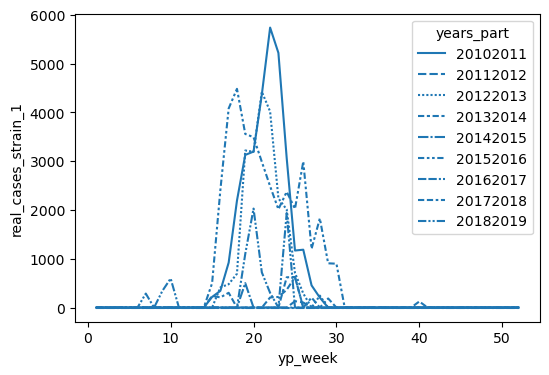

In [3]:
plt.subplots(1,1,figsize=(6,4))
sns.lineplot(x = epid_df.yp_week,
            y = epid_df.real_cases_strain_1, 
             style=epid_df.years_part)

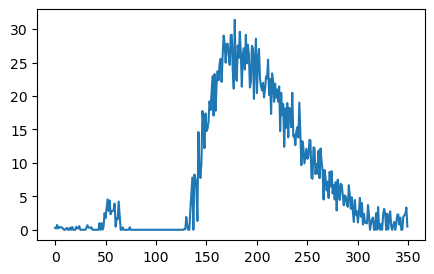

In [4]:
plt.subplots(1,1,figsize=(5,3))
model = AESurrogateModel(10**5, 'sw')
q = model.simulate(0.005,0.87)
q[q<0] = 0
plt.plot(q)

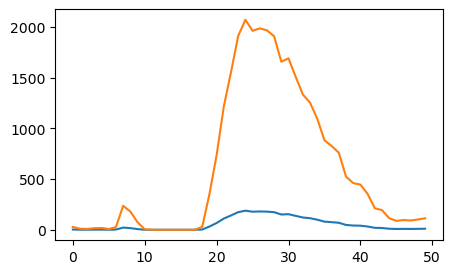

In [5]:
plt.subplots(1,1,figsize=(5,3))
kk = pd.Series(q).groupby(pd.Series(q).index // 7).sum() 
plt.plot(kk)
plt.plot(kk*11)

In [6]:
pd.Series(q).groupby(pd.Series(q).index // 7).sum().values.shape

(50,)

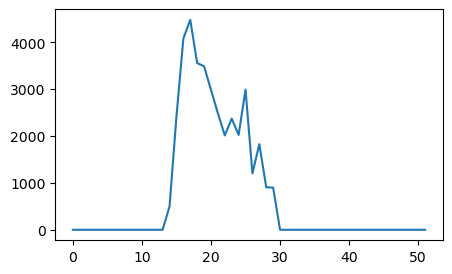

In [7]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
year = 2015
pop = epid_df.total_population.mean()
incidence = epid_df[(epid_df.years_part==f'{year}{year+1}')
                   ].real_cases_strain_1.values

aa = ax.plot(incidence)

In [8]:
ax.get_xticks()[1:]

array([ 0., 10., 20., 30., 40., 50., 60.])

In [9]:
gamma = [0.3]
delta=[0.2]
n_nodes=[100000]
top = [False] #is BA?
true_tau, true_alpha = 0,0

(pop/n_nodes)[0]

np.float64(11.744460959692898)

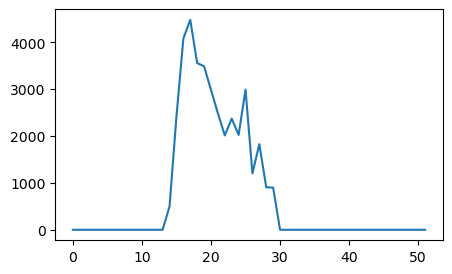

In [10]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
year = 2015
pop = epid_df[(epid_df.years_part==f'{year}{year+1}')].total_population.mean()
incidence = epid_df[(epid_df.years_part==f'{year}{year+1}')
                   ].real_cases_strain_1.values

aa = ax.plot(incidence)

In [104]:
koeff = [(pop/n_nodes)[0]]
draws=500
chains = 4
epsilon=500
idatat = calibr(draws=draws, chains =chains, epsilon=epsilon, 
       incidence=incidence, koeff = koeff)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


It took  82.7251467704773 sec



0.08914011552812041 0.9870172372473303
[0]


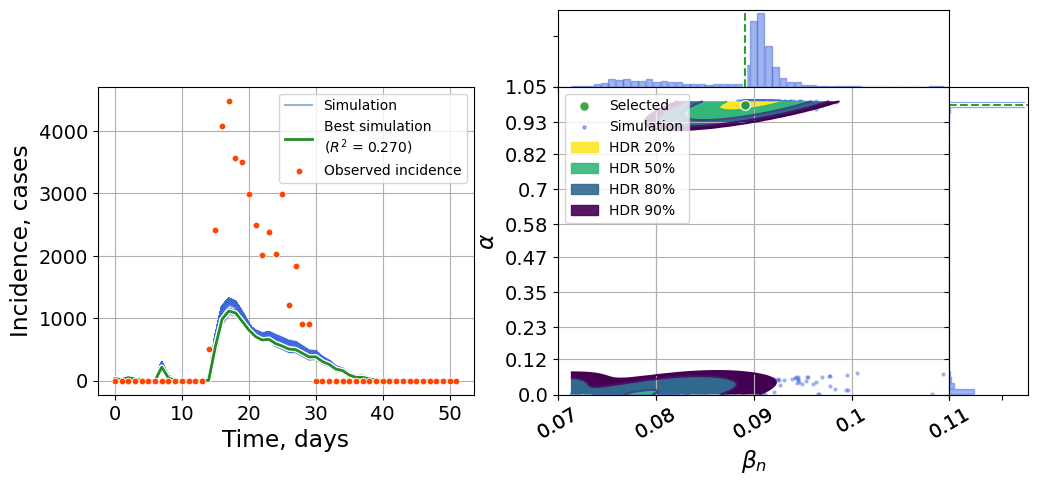

In [122]:
# with_switch,num_runs,frac,gamma,\
#    delta,n_nodes,top,koeff, shift
network_params=[[False],[0],[0],[gamma],
                [delta],[n_nodes], top, koeff, 1]
plot_funcs.plot_calib(np.array(incidence), idatat, 0, 0, 
               network_params, pred=False, with_observed=False)

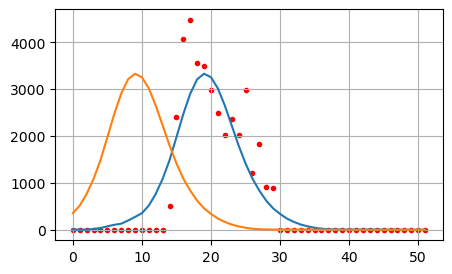

In [58]:
plt.subplots(1,1, figsize=(5,3))
temp_inc = incidence.copy()
temp_sim = idatat.posterior_predictive.sim.stack(samples=("draw", 
                                                        "chain")
                                     ).mean(axis=1)
plt.scatter(np.arange(temp_inc.shape[0]), temp_inc, 
            marker='.', color='red')
plt.plot(temp_sim)
plt.plot(pd.Series(temp_sim).shift(-10).fillna(0))

plt.grid()

In [11]:
koeff = [1]
draws= 200
chains = 3
shift=1
epsilon=2000

idatat2 = abc_calib.calibr(draws=draws, chains =chains, 
                          epsilon=epsilon, shift=shift,
                          incidence=incidence, koeff = koeff)

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  20.56495761871338 sec



0.7519992485845791 0.46202124919755
shift: 1
samples with r2>= 0.7 : 0.84
samples with r2>= 0.75 : 0.67
samples with r2>= 0.8 : 0.28
samples with r2>= 0.85 : 0.0
samples with r2>= 0.9 : 0.0
r2 mean: 0.755


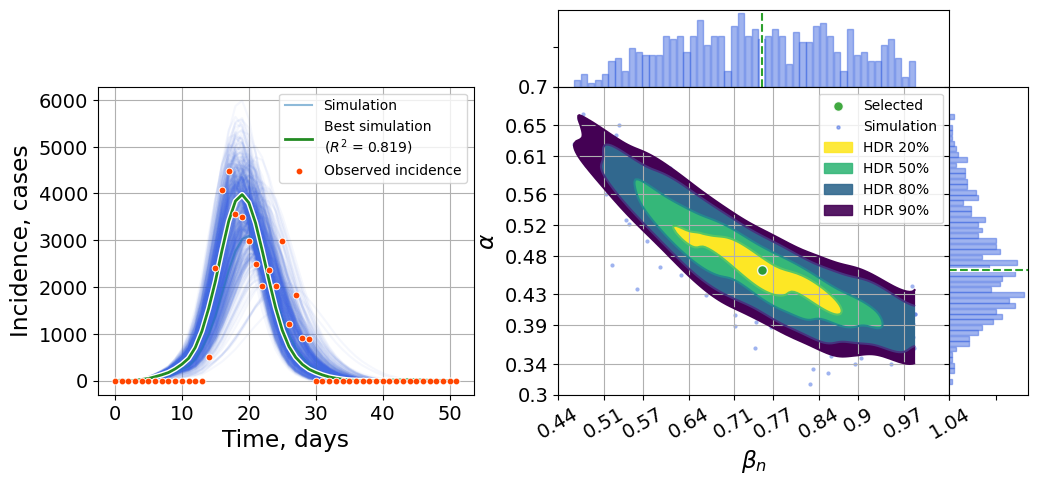

In [12]:
# with_switch,num_runs,frac,gamma,\
#    delta,n_nodes,top,koeff, shift
network_params=[[False],[0],[0],[gamma],
                [delta],[n_nodes], top, koeff, shift]
plot_funcs.plot_calib(np.array(incidence), idatat2, 0, 0, 
               network_params, pred=False, with_observed=False)

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  19.832324266433716 sec

0.5960627986908219 0.5199435347810081
shift: -1
samples with r2>= 0.7 : 0.8
samples with r2>= 0.75 : 0.58
samples with r2>= 0.8 : 0.28
samples with r2>= 0.85 : 0.0
samples with r2>= 0.9 : 0.0
r2 mean: 0.746


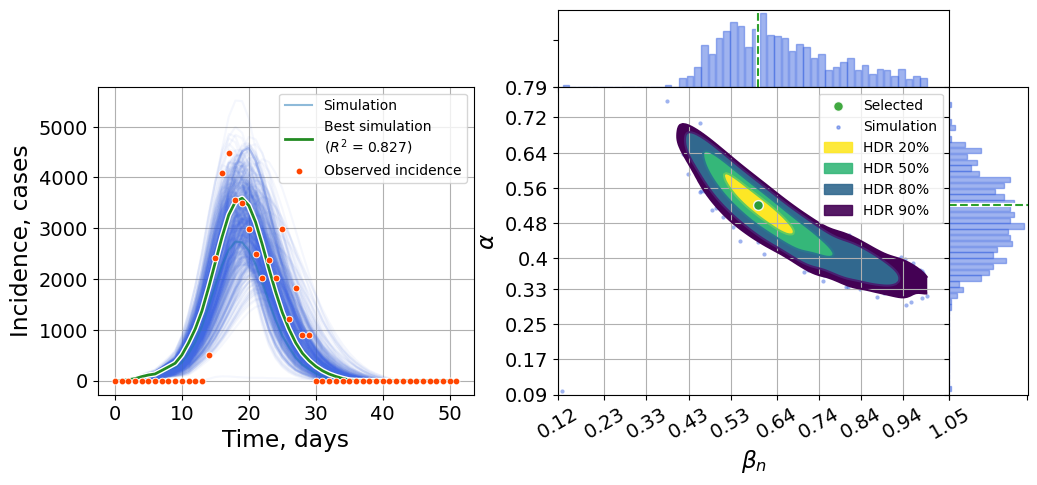

In [13]:
koeff = [1]
draws= 200
chains = 3
shift= -1
epsilon=2000

idatat = abc_calib.calibr(draws=draws, chains =chains, 
                          epsilon=epsilon, shift=shift,
                          incidence=incidence, koeff = koeff)
# with_switch,num_runs,frac,gamma,\
#    delta,n_nodes,top,koeff, shift
network_params=[[False],[0],[0],[gamma],
                [delta],[n_nodes], top, koeff, shift]
plot_funcs.plot_calib(np.array(incidence), idatat, 0, 0, 
               network_params, pred=False, with_observed=False)

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "D:\Programs\Anaconda\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 483, in superreload
    module = reload(module)
  File "D:\Programs\Anaconda\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]
Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  19.182822942733765 sec

0.8289043314237167 0.4497399723775524
shift: 2
samples with r2>= 0.7 : 0.81
samples with r2>= 0.75 : 0.6
samples with r2>= 0.8 : 0.0
samples with r2>= 0.85 : 0.0
samples with r2>= 0.9 : 0.0
r2 mean: 0.738


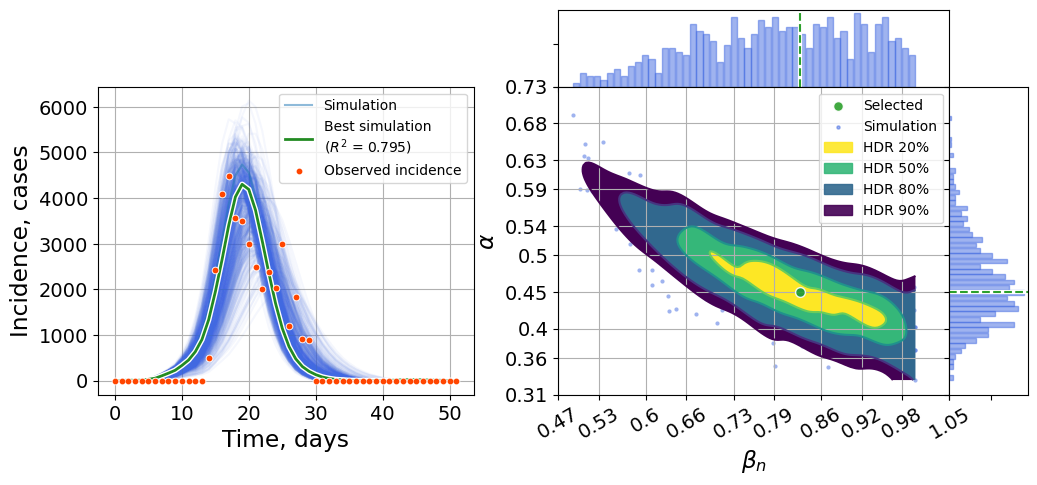

In [15]:
koeff = [1]
draws= 200
chains = 3
shift= 2
epsilon=2000

idatat = abc_calib.calibr(draws=draws, chains =chains, 
                          epsilon=epsilon, shift=shift,
                          incidence=incidence, koeff = koeff)
# with_switch,num_runs,frac,gamma,\
#    delta,n_nodes,top,koeff, shift
network_params=[[False],[0],[0],[gamma],
                [delta],[n_nodes], top, koeff, shift]
plot_funcs.plot_calib(np.array(incidence), idatat, 0, 0, 
               network_params, pred=False, with_observed=False)

In [17]:
np.arange(-10,10)

array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
         3,   4,   5,   6,   7,   8,   9])

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  275.3883469104767 sec

0.3554846648323727 0.6749000335990576


Initializing SMC sampler...
Sampling 3 chains in 3 jobs


shift: -10
samples with r2>= 0.7 : 0.14
samples with r2>= 0.75 : 0.0
samples with r2>= 0.8 : 0.0
samples with r2>= 0.85 : 0.0
samples with r2>= 0.9 : 0.0
r2 mean: 0.61


...

It took  227.69873929023743 sec

0.9626970700133796 0.4434467356556805


Initializing SMC sampler...
Sampling 3 chains in 3 jobs


shift: 8
samples with r2>= 0.7 : 0.0
samples with r2>= 0.75 : 0.0
samples with r2>= 0.8 : 0.0
samples with r2>= 0.85 : 0.0
samples with r2>= 0.9 : 0.0
r2 mean: -0.062


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  135.699138879776 sec

0.9201248957508902 0.4332307742585798
shift: 9
samples with r2>= 0.7 : 0.0
samples with r2>= 0.75 : 0.0
samples with r2>= 0.8 : 0.0
samples with r2>= 0.85 : 0.0
samples with r2>= 0.9 : 0.0
r2 mean: -0.287


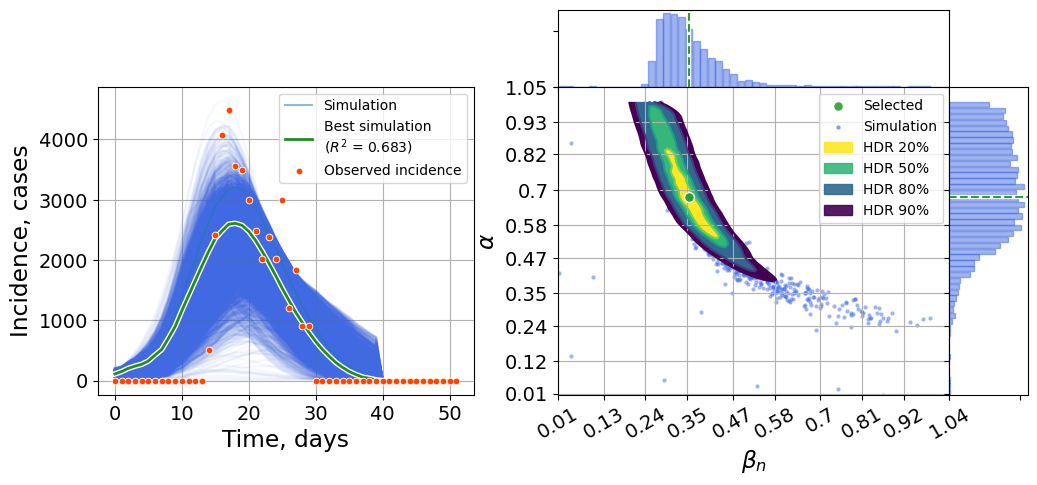

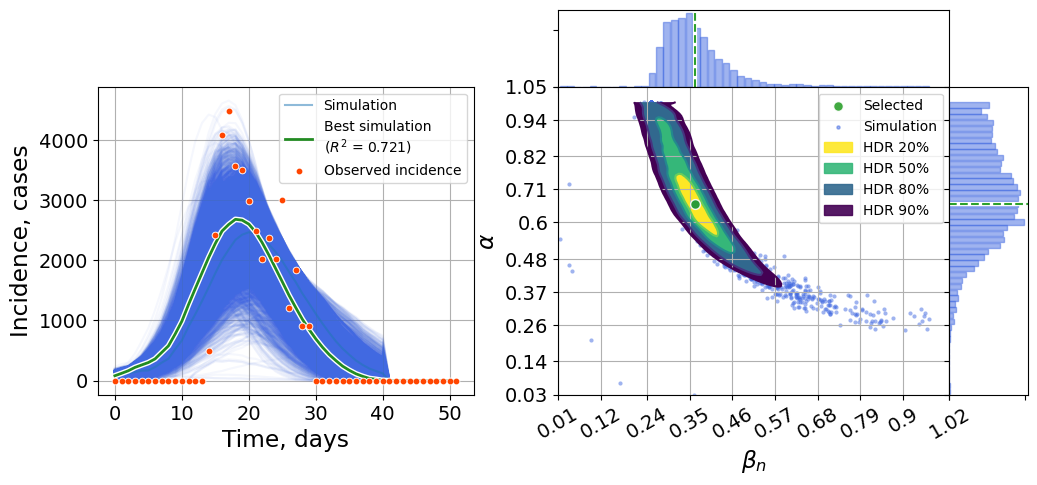

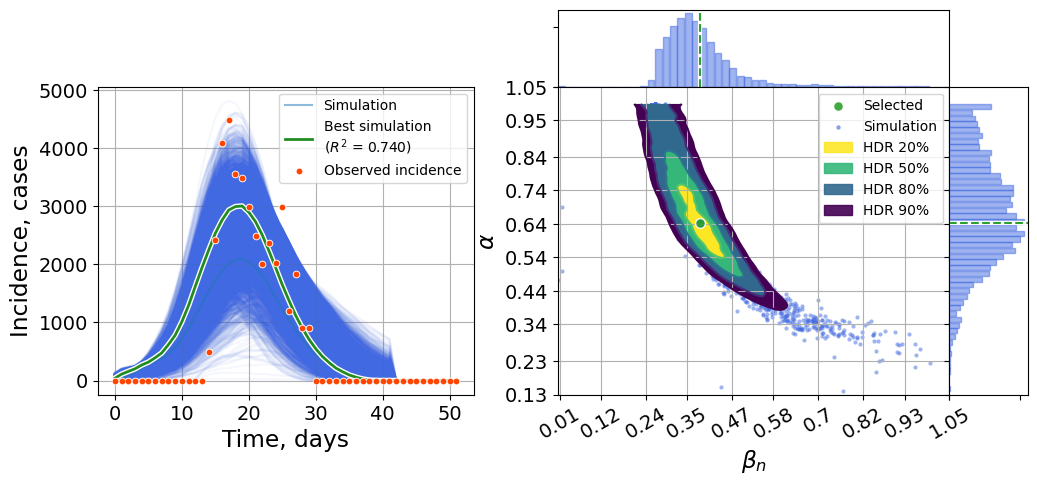

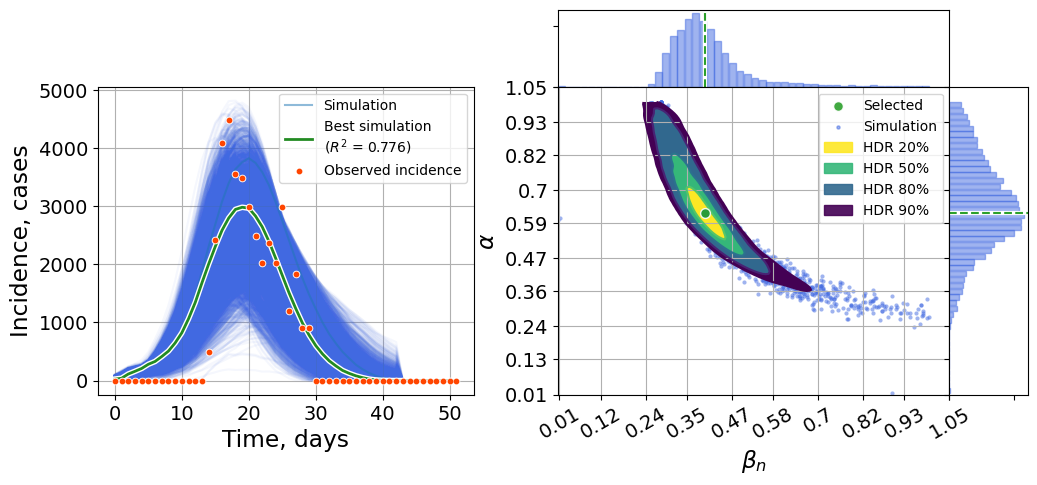

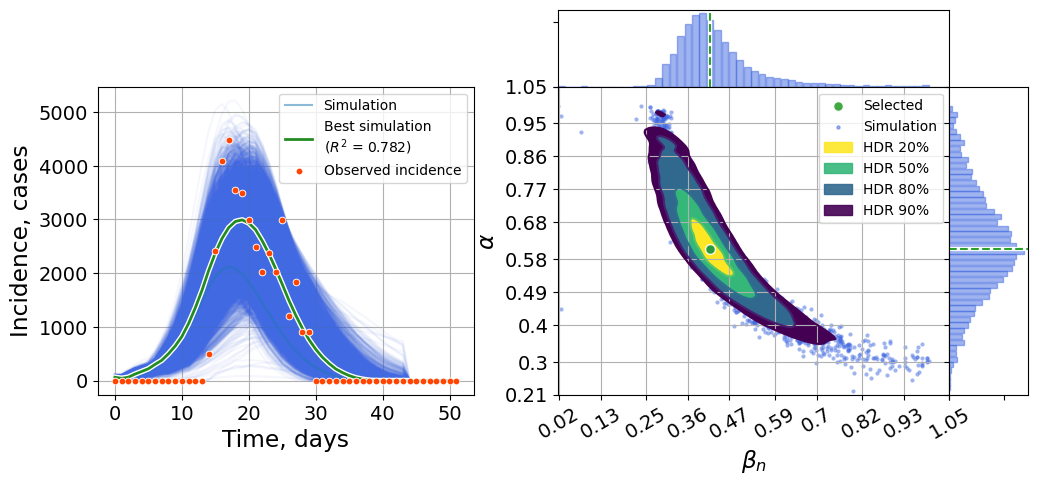

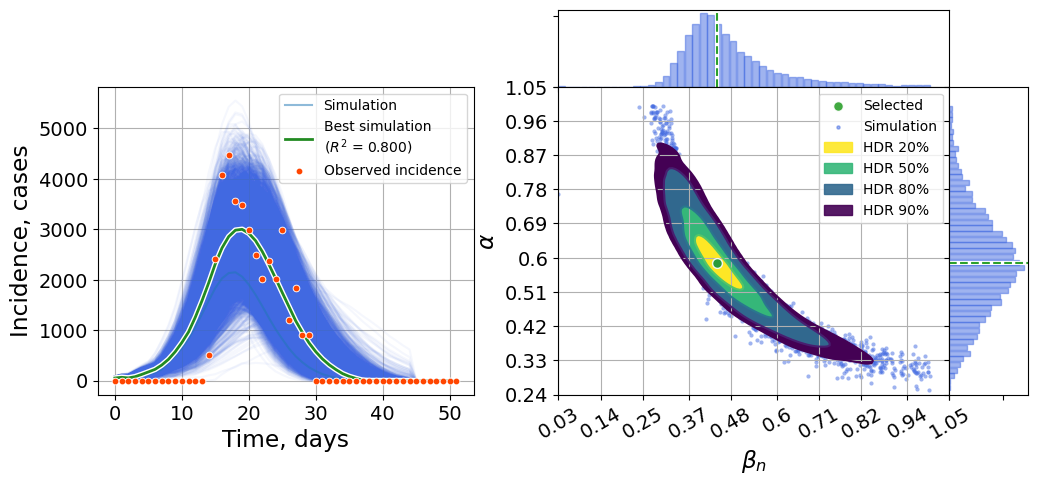

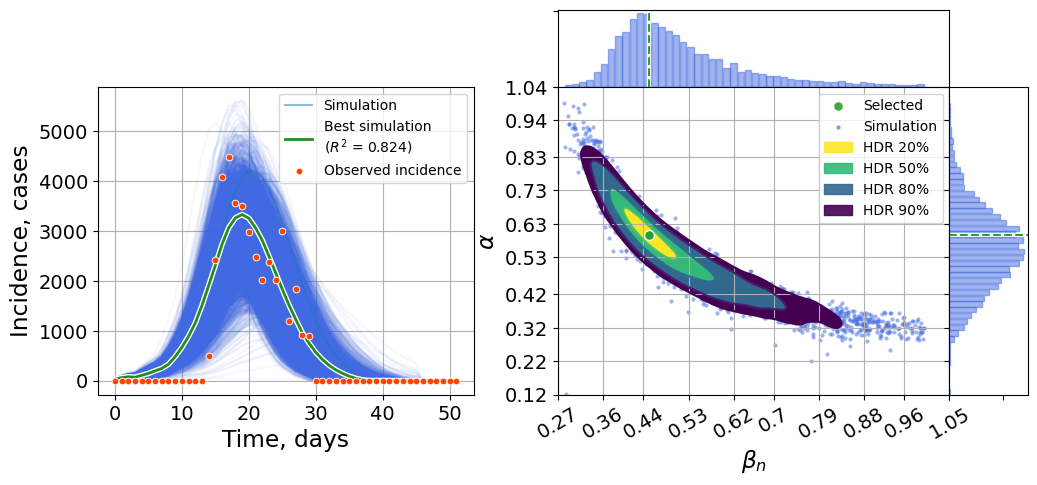

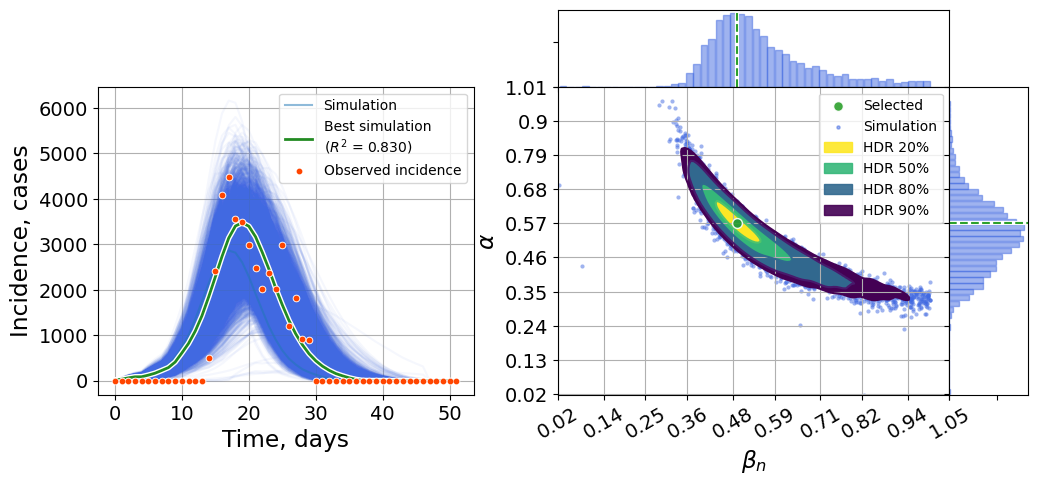

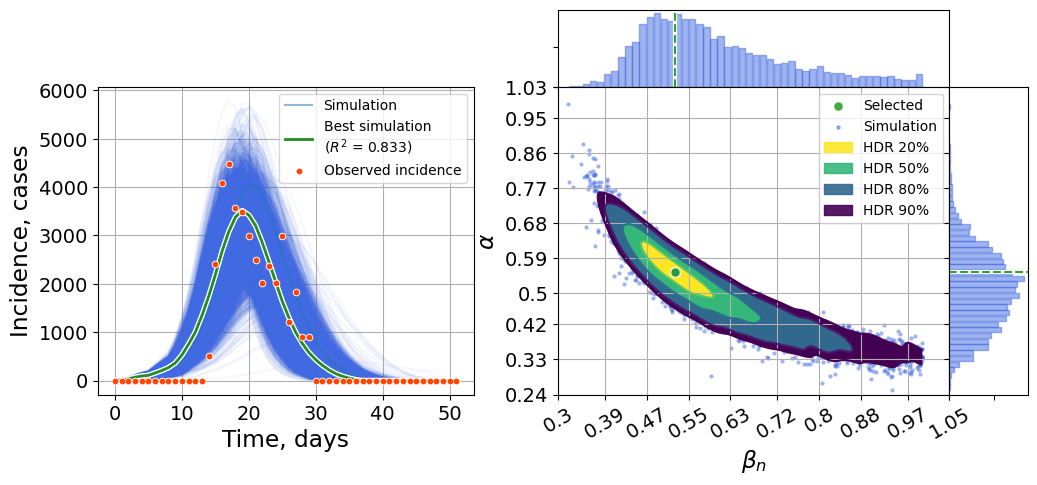

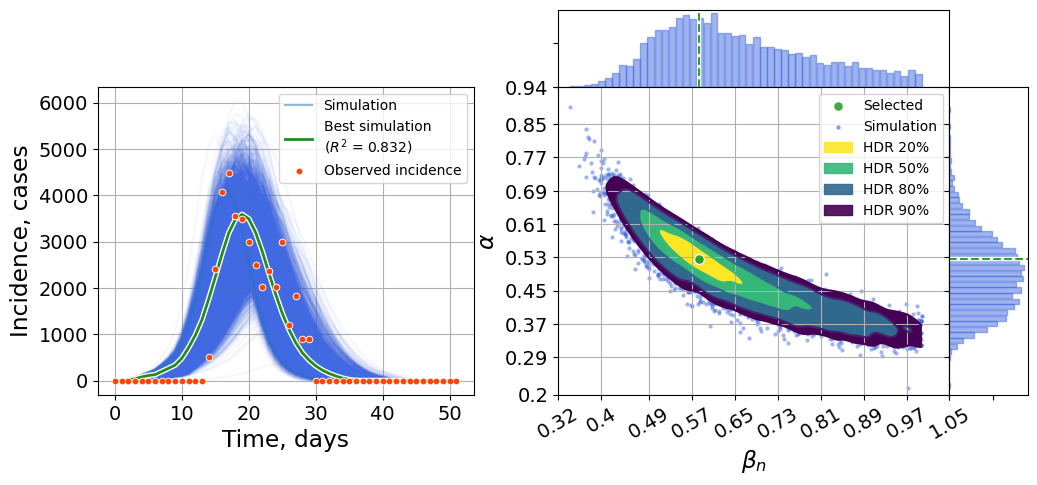

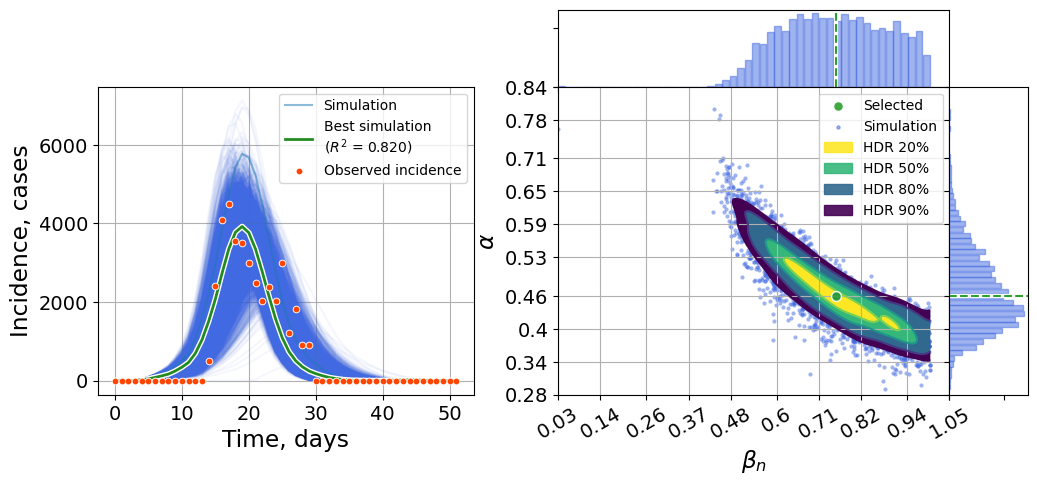

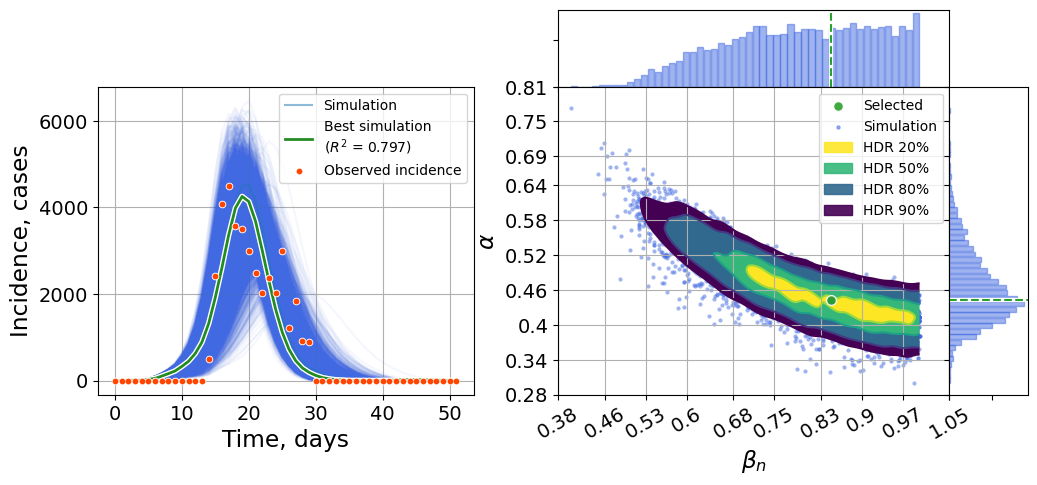

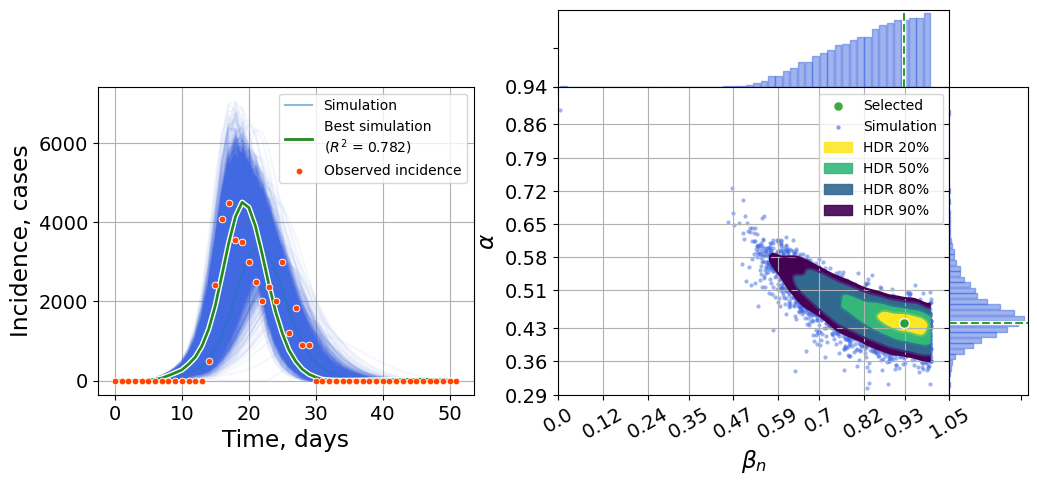

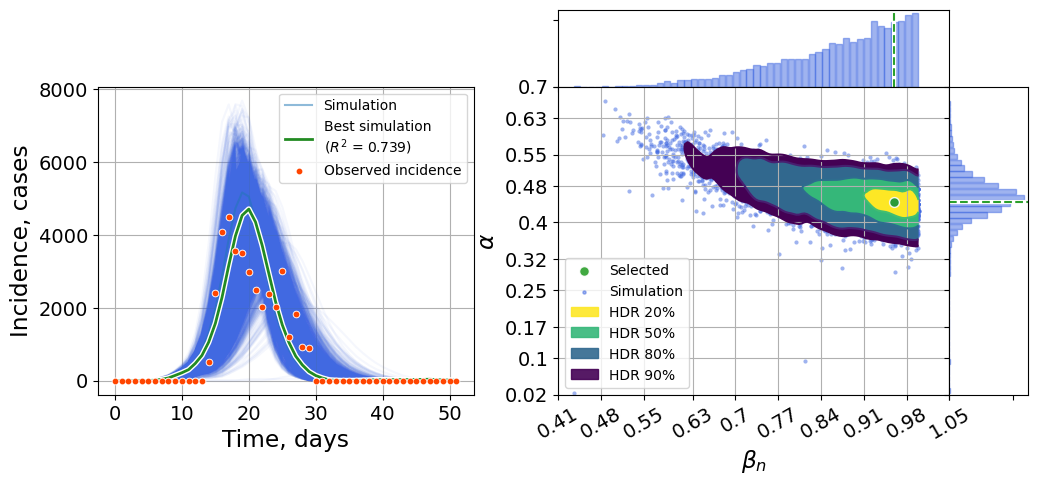

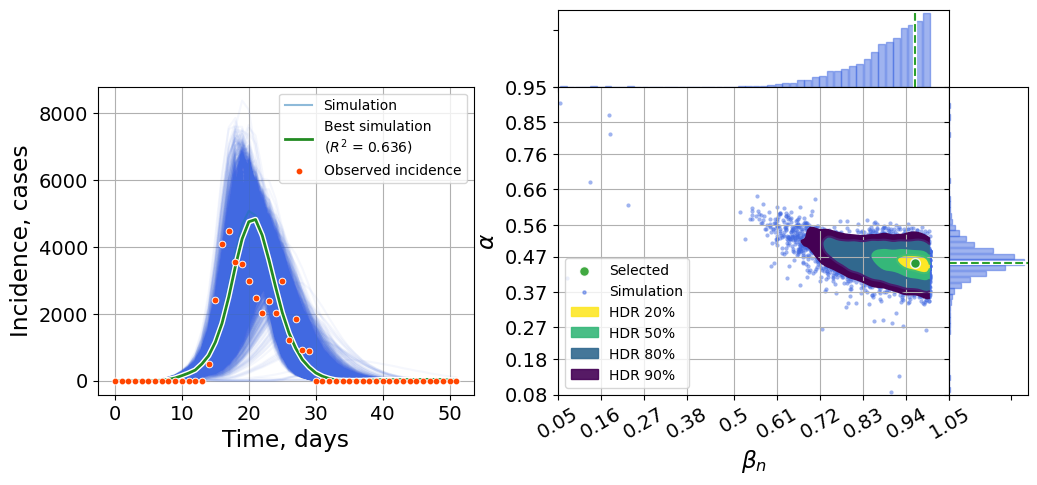

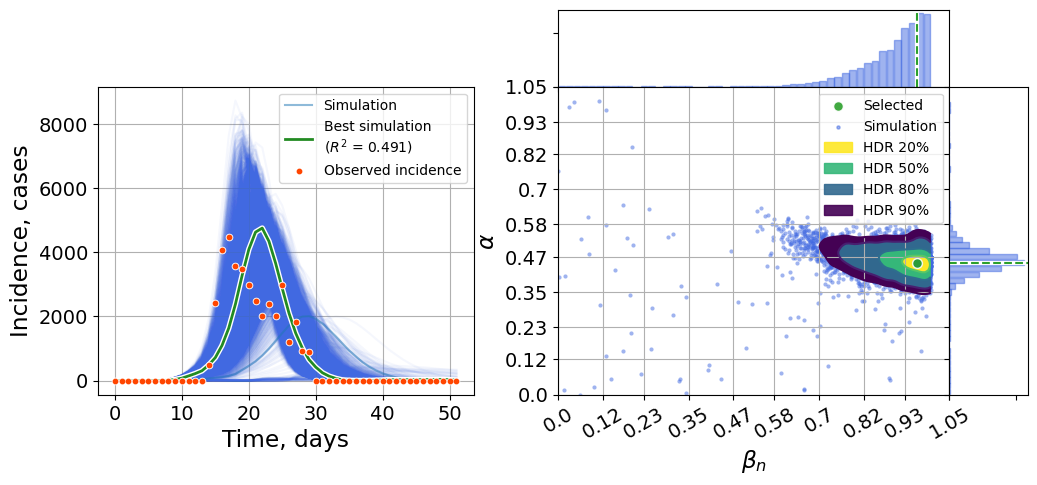

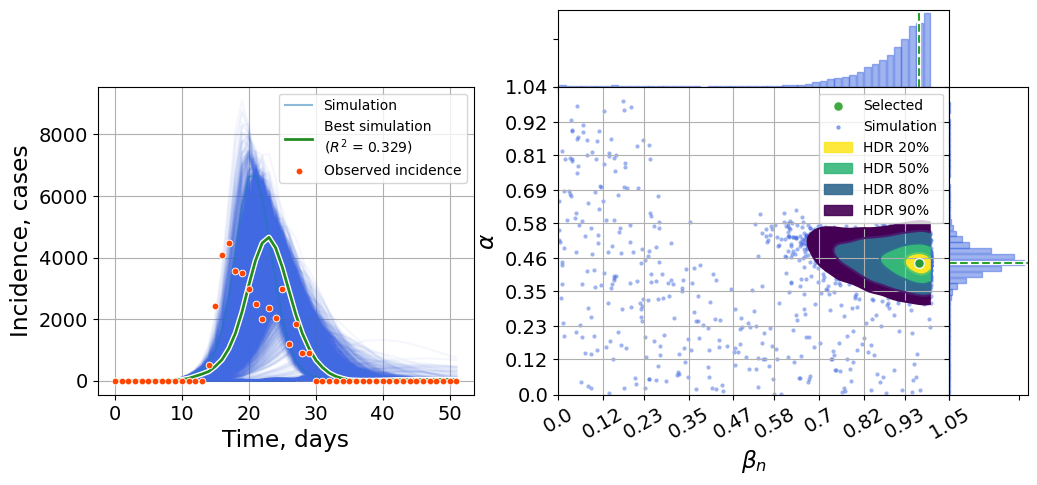

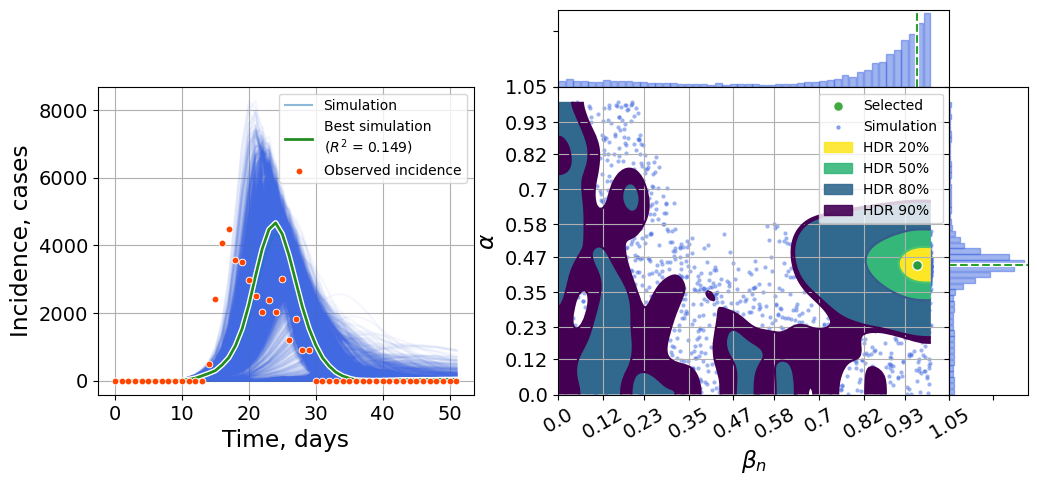

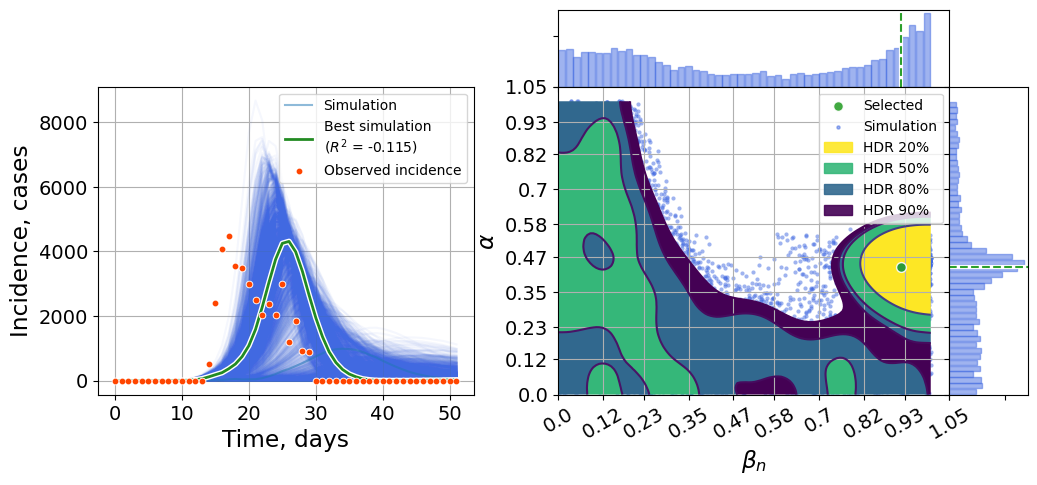

In [18]:
for shift in np.arange(-10,10):
    if shift!=0:
        koeff = [1]
        draws= 2000
        chains = 3
        #shift= -1
        epsilon=2000

        idatat = abc_calib.calibr(draws=draws, chains =chains, 
                                  epsilon=epsilon, shift=shift,
                                  incidence=incidence, koeff = koeff)
        # with_switch,num_runs,frac,gamma,\
        #    delta,n_nodes,top,koeff, shift
        network_params=[[False],[0],[0],[gamma],
                        [delta],[n_nodes], top, koeff, shift]
        plot_funcs.plot_calib(np.array(incidence), idatat, 0, 0, 
                       network_params, pred=False, with_observed=False)


## different year curve

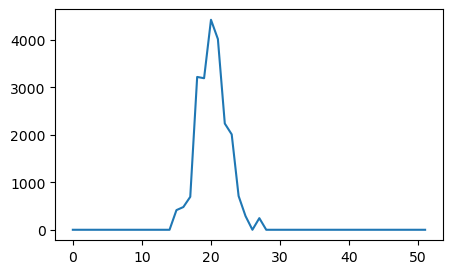

In [138]:
fig, ax = plt.subplots(1,1,figsize=(5,3))
year = 2012
pop = epid_df[(epid_df.years_part==f'{year}{year+1}')].total_population.mean()
incidence = epid_df[(epid_df.years_part==f'{year}{year+1}')
                   ].real_cases_strain_1.values

aa = ax.plot(incidence)

In [139]:
koeff = [1]
draws=500
chains = 4
epsilon=500
calibr(draws=draws, chains =chains, epsilon=epsilon, incidence=incidence,
      koeff = koeff)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Sampling: [sim]


It took  41.33688426017761 sec



0.8430599182858058 0.38391456021112674
[0]


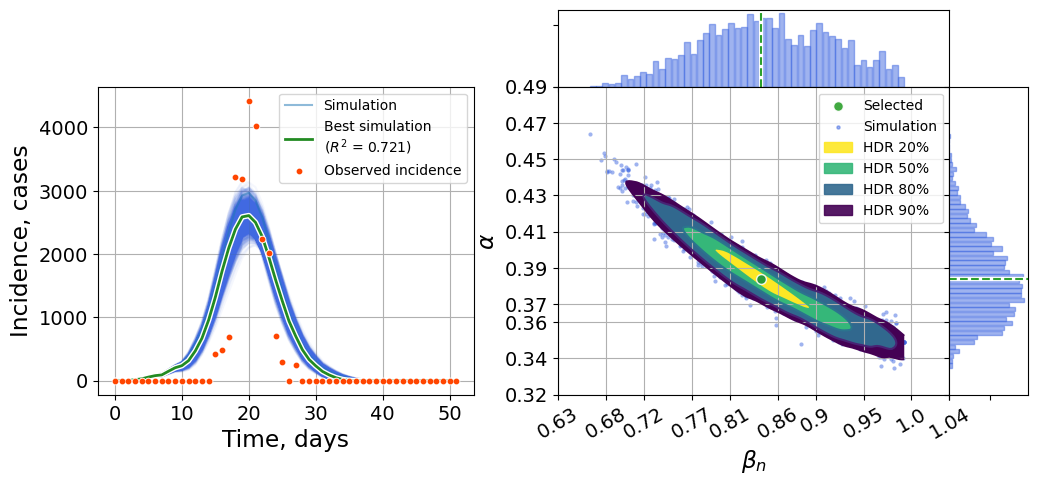

In [141]:
idatat = az.from_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[[False],[0],[0],[gamma],[delta],[n_nodes], top, koeff]
plot_funcs.plot_calib(np.array(incidence), idatat, 
               true_tau, true_alpha, 
               network_params, pred=False, with_observed=False)

In [142]:
koeff = [(pop/n_nodes)[0]]
draws=500
chains = 4
epsilon=500
calibr(draws=draws, chains =chains, epsilon=epsilon, incidence=incidence,
      koeff = koeff)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


It took  54.65354537963867 sec



0.08361463639665581 0.01801724949592674
[0]


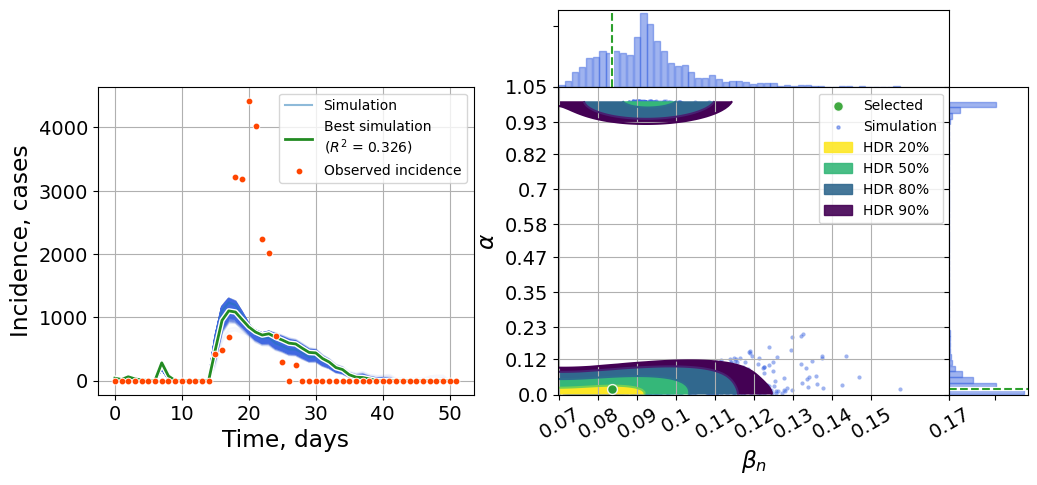

In [144]:
idatat = az.from_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[[False],[0],[0],[gamma],[delta],[n_nodes], top, koeff]
plot_funcs.plot_calib(np.array(incidence), idatat, 
               true_tau, true_alpha, 
               network_params, pred=False, with_observed=False)